In [19]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
import sys
sys.path

sys.path.insert(0,'/mnt/c/Users/Arthur Zhou/GitHub/gtx_victor')
sys.path

['/mnt/c/Users/Arthur Zhou/GitHub/gtx_victor',
 '/mnt/c/Users/Arthur Zhou/GitHub/gtx_victor',
 '/home/zhouarth/anaconda3/envs/pytorch3.10/lib/python310.zip',
 '/home/zhouarth/anaconda3/envs/pytorch3.10/lib/python3.10',
 '/home/zhouarth/anaconda3/envs/pytorch3.10/lib/python3.10/lib-dynload',
 '',
 '/home/zhouarth/anaconda3/envs/pytorch3.10/lib/python3.10/site-packages',
 '/tmp/tmpvn2uugv6']

In [38]:
from pl_wrapper import Unet
from datamodule import FluorescenceDataModule, FluorescenceTestDataModule
import pytorch_lightning as pl
from dataset import FluorescenceDataset
import torch
import os


In [26]:
train = '/mnt/c/Users/Arthur Zhou/Documents/Data/MCX/padded_DL_nImages1000_newOP_elecNoise.mat' #mcx padded new'
test="/mnt/c/Users/Arthur Zhou/UHN/GTx - DalyShare/ImageData/DL/20221220_AWS/SubmarineTestingDataAll/20250108_1000_CSH_PpIX/DL_nImages1000.mat"
params = {
    'activation': 'relu',
    'optimizer': 'Adam',
    'epochs': 1,
    'nF': 6,
    'learningRate': 1e-3, #changed 
    'batch': 32,
    'xX': 101,
    'yY': 101,
    'decayRate': 0.3,
    'patience': 20,
    'scaleFL': 10e4,
    'scaleOP0': 10,
    'scaleOP1': 1,
    'scaleDF': 1,
    'scaleQF': 1,
    'scaleRE': 1,
    'nFilters3D': 128,
    'kernelConv3D': [3,3,3],
    'strideConv3D': [1,1,1],
    'nFilters2D': 128,
    'kernelConv2D': [3,3],
    'strideConv2D': [1,1],
    'data_path': test,
    'seed':1024,
    'normalize': 0,
    'train_subset': 500, # set to None to use all training data
    'sagemaker': 0
}
# can add 'testpath' if you want to load test dataloaders

# Init Dataset
scale_params = {
    'fluorescence': params['scaleFL'],
    'mu_a': params['scaleOP0'],
    'mu_s': params['scaleOP1'],
    'depth': params['scaleDF'],
    'concentration_fluor': params['scaleQF'],
    'reflectance': params['scaleRE']
}


In [5]:
import mat73
a = mat73.loadmat(test)

In [6]:
a.keys()

dict_keys(['DF', 'F', 'OP', 'QF', 'RE'])

# Dataloaders

In [27]:
data_mod = FluorescenceDataModule(params, scale_params, batch_size = params['batch'])
data_mod.prepare_data()
data_mod.setup()

Normalize: 0
FFFFF: [(1.807761e-06, 0.0009339817), (1.6067189e-07, 0.00052120234), (3.4686018e-08, 0.00036927356), (1.3818778e-08, 0.0002879503), (1.0965559e-08, 0.00022427096), (8.841042e-09, 0.0001762569)]
OOOOO: [(0.0034044283, 0.010998148), (0.95710427, 1.0333169)]
You are not normalizing the data
You are not normalizing the data
You are not normalizing the data
Dataset shapes: torch.Size([500, 101, 101, 6]) torch.Size([500, 101, 101]) torch.Size([500, 101, 101]) torch.Size([500, 101, 101]) torch.Size([500, 101, 101])
Dataset shapes: torch.Size([100, 101, 101, 6]) torch.Size([100, 101, 101]) torch.Size([100, 101, 101]) torch.Size([100, 101, 101]) torch.Size([100, 101, 101])
Dataset shapes: torch.Size([100, 101, 101, 6]) torch.Size([100, 101, 101]) torch.Size([100, 101, 101]) torch.Size([100, 101, 101]) torch.Size([100, 101, 101])
datamodule is setup


In [8]:
it = iter(data_mod.train_dataloader())

In [11]:
print(next(it)[0].shape,
next(it)[1].shape,
next(it)[2].shape,
next(it)[3].shape,)
#  self.fluorescence[idx], self.op[idx], self.concentration[idx], self.depth[idx]

torch.Size([32, 1, 6, 101, 101]) torch.Size([32, 2, 101, 101]) torch.Size([32, 1, 101, 101]) torch.Size([32, 1, 101, 101])


In [48]:
from lightning.pytorch.loggers import CSVLogger
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import ModelCheckpoint

# Training

In [ ]:
#load data
data_mod = FluorescenceDataModule(params, scale_params, batch_size=params['batch'])
data_mod.prepare_data()
data_mod.setup()

#pl model init
model = Unet(params=params)

#change this for saving chekcpoints and loss
experiment_name ='testing_lightning'
root_dir = "/mnt/c/Users/Arthur Zhou/Documents/ML/logger"
save_dir =os.path.join(root_dir,experiment_name)
os.makedirs(save_dir, exist_ok=True)

#experiment_name = " " + "_log"
#add version arg if you want to name the output dir custom on each run.
logger = CSVLogger(save_dir=save_dir, name=experiment_name)

# training
checkpoint_callback = ModelCheckpoint(dirpath=save_dir,
                                      save_last=True,)

trainer = Trainer(callbacks=[checkpoint_callback],
                  accelerator="gpu" if torch.cuda.is_available() else "cpu",
                  log_every_n_steps=10,
                  logger=logger,
                  max_epochs=1) #change this in params if you want to use params

#trainer.fit(model, datamodule=data_mod)


Normalize: 0
FFFFF: [(1.807761e-06, 0.0009339817), (1.6067189e-07, 0.00052120234), (3.4686018e-08, 0.00036927356), (1.3818778e-08, 0.0002879503), (1.0965559e-08, 0.00022427096), (8.841042e-09, 0.0001762569)]
OOOOO: [(0.0034044283, 0.010998148), (0.95710427, 1.0333169)]
You are not normalizing the data
You are not normalizing the data
You are not normalizing the data
Dataset shapes: torch.Size([500, 101, 101, 6]) torch.Size([500, 101, 101]) torch.Size([500, 101, 101]) torch.Size([500, 101, 101]) torch.Size([500, 101, 101])
Dataset shapes: torch.Size([100, 101, 101, 6]) torch.Size([100, 101, 101]) torch.Size([100, 101, 101]) torch.Size([100, 101, 101]) torch.Size([100, 101, 101])
Dataset shapes: torch.Size([100, 101, 101, 6]) torch.Size([100, 101, 101]) torch.Size([100, 101, 101]) torch.Size([100, 101, 101]) torch.Size([100, 101, 101])
datamodule is setup


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


# Testing

In [73]:
import numpy as np
import os
import matplotlib.pyplot as plt
import torch

In [ ]:
from skimage.filters import threshold_otsu
def pred_phantom(pred, idx, draw=False, depth_padding=10.0, thresh =True):
    """
    pred: batch prediction form trainer.test organized as dict

    """
    true_depth = pred['true_depth'][idx, ...].numpy()
    true_depth[depth==0] = depth_padding

    input1 = tf.convert_to_tensor(op, dtype=tf.float32)
    input2 = tf.convert_to_tensor(fl, dtype=tf.float32)

    outputs = model([input1, input2], training=False)

    pred_conc = outputs[0].numpy()
    pred_depth = outputs[1].numpy()

    if thresh:
      print("using otsu thresh")
      thresh = threshold_otsu(pred_depth[0])
      mask = pred_depth[0] < thresh
      masked_img = np.where(mask, pred_depth[0], 0)
    else:
      pred_depth_masked = np.where(pred_conc[0] < np.float32(0.1), 0, pred_depth[0])
      pred_depth_masked = np.where(pred_depth_masked >= np.float32(10.0), 0, pred_depth_masked)
      masked_img = pred_depth_masked
      #display(pred_depth_masked.max(), pred_depth_masked.min())



    gt = depth[0].copy()
    gt[gt==depth_padding]=0

    try:
      max_gt = np.max(gt[gt!=depth_padding])
    except:
      max_gt = depth_padding
      #print("all padding")
    p = masked_img.copy()

    depth_arr = depth[0].flatten()
    pred_depth_arr = pred_depth[0].flatten()

    min_gt_value = np.min(depth_arr)
    min_gt_px = np.argmin(depth_arr)
    min_pred_value = np.min(pred_depth_arr)
    min_pred_px = np.argmin(pred_depth_arr)
    err_min = np.abs(min_gt_value-min_pred_value)
    print(f"Diff： {err_min}") if draw else None

    draw_pred(gt, masked_img) if draw else None

    return err_min, gt, masked_img


In [269]:
# model checkpoints
dropout_2050_mcx = '/mnt/c/Users/Arthur Zhou/GitHub/gtx_victor/code_py/model_params/lightning_20_50_dropout_mcx/modelckpt/last.ckpt'


#testing data paths
# testing data
all_tumors = '/mnt/c/Users/Arthur Zhou/GitHub/gtx_victor/data/phantom/all_tumors.mat' #tumor 1 and tumor 18
local_hikaru_test_200= "/mnt/c/Users/Arthur Zhou/Documents/ML/Data/SubmarineTestingDataAll/20250107_20_mandolin_countours_shift_0_10_tumour_1_21_PpIX/DL_nImages200.mat"
hikaru_liquid_phantom = "/mnt/c/Users/Arthur Zhou/UHN/GTx - DalyShare/ImageData/SL/SFDIData/20250811_all_tumours_recrop/All_combined/combinedVariables.mat" #no dpeth map
hikaru_36_with_depth = "/mnt/c/Users/Arthur Zhou/Documents/ML/Data/SubmarineTestingDataAll/36_hikaru_depth.mat" #has depth map


In [196]:
model = Unet(params)
model.eval()

trainer_default = Trainer(accelerator="gpu" if torch.cuda.is_available() else "cpu", log_every_n_steps=1)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/zhouarth/anaconda3/envs/pytorch3.10/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default


In [202]:
model_eval = Unet.load_from_checkpoint(dropout_2050_mcx, params=params)
model_eval.eval()

trainer = Trainer(accelerator="gpu" if torch.cuda.is_available() else "cpu",
                  log_every_n_steps=10,
                  logger=logger,
                  max_epochs=60) #change this in params if you want to use params

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [207]:
ckp = torch.load(dropout_2050_mcx, map_location=torch.device('cpu'))

In [210]:
ckp.keys()

dict_keys(['epoch', 'global_step', 'pytorch-lightning_version', 'state_dict', 'loops', 'callbacks', 'optimizer_states', 'lr_schedulers'])

In [271]:
test_params = {
    'testpath': hikaru_36_with_depth,
    'batch': 8,
    'seed': 1024,
    'normalize': 0

}

data_module_test = FluorescenceTestDataModule(params=test_params, scale_params=scale_params, batch_size=test_params['batch'], )
data_module_test.setup()


Normalize: 0
You are not normalizing the data
you are padding background (0) with a depth of 10.0
Dataset shapes: torch.Size([36, 101, 101, 6]) torch.Size([36, 101, 101]) torch.Size([36, 101, 101]) torch.Size([36, 101, 101]) torch.Size([36, 101, 101])


In [131]:
# check our loaders here
ts = iter(data_module_test.test_dataloader())

next(ts)[2].shape

torch.Size([8, 1, 101, 101])

In [272]:
trainer_default.test(model, datamodule=data_module_test)

Normalize: 0


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


You are not normalizing the data
you are padding background (0) with a depth of 10.0
Dataset shapes: torch.Size([36, 101, 101, 6]) torch.Size([36, 101, 101]) torch.Size([36, 101, 101]) torch.Size([36, 101, 101]) torch.Size([36, 101, 101])
Testing DataLoader 0:   0%|          | 0/5 [00:00<?, ?it/s]Batch 0 of 4
torch.Size([8, 1, 6, 101, 101]) torch.Size([8, 2, 101, 101]) torch.Size([8, 1, 101, 101]) torch.Size([8, 1, 101, 101])
pad before tensor(-0.0387, device='cuda:0') tensor(0.0008, device='cuda:0') tensor(-0.0096, device='cuda:0')
pad after tensor(-0.0387, device='cuda:0') tensor(0.0008, device='cuda:0') tensor(-0.0096, device='cuda:0')
pred_qf.shape: torch.Size([8, 1, 101, 101]) pred_depth.shape: torch.Size([8, 1, 101, 101]) concentration_fluor.shape: torch.Size([8, 1, 101, 101]) depth.shape: torch.Size([8, 1, 101, 101]) fluorescence.shape: torch.Size([8, 1, 6, 101, 101]) op.shape: torch.Size([8, 2, 101, 101])
Total Test Loss: 15.003034591674805 | Pred QF Loss: 5.037542819976807 | P

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      test_depth_loss      │     9.752862930297852     │
│         test_loss         │    14.790627479553223     │
│       test_qf_loss        │     5.037766456604004     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 14.790627479553223,
  'test_qf_loss': 5.037766456604004,
  'test_depth_loss': 9.752862930297852}]

In [198]:
pred_default ={
    'true_depth': model.test_depth.squeeze(1),
    "pred_depth": model.pred_depth.squeeze(1),
    "true_f": model.test_f.squeeze(1),
    "pred_f": model.pred_qf.squeeze(1),
    "true_conc" :  model.test_f.squeeze(1)
}


In [273]:
trainer.test(model = model_eval, datamodule=data_module_test)

Normalize: 0


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


You are not normalizing the data
you are padding background (0) with a depth of 10.0
Dataset shapes: torch.Size([36, 101, 101, 6]) torch.Size([36, 101, 101]) torch.Size([36, 101, 101]) torch.Size([36, 101, 101]) torch.Size([36, 101, 101])
Testing DataLoader 0:   0%|          | 0/5 [00:00<?, ?it/s]Batch 0 of 4
torch.Size([8, 1, 6, 101, 101]) torch.Size([8, 2, 101, 101]) torch.Size([8, 1, 101, 101]) torch.Size([8, 1, 101, 101])
pad before tensor(-0.0292, device='cuda:0') tensor(0.5196, device='cuda:0') tensor(0.0277, device='cuda:0')
pad after tensor(-0.0292, device='cuda:0') tensor(0.5196, device='cuda:0') tensor(0.0277, device='cuda:0')
pred_qf.shape: torch.Size([8, 1, 101, 101]) pred_depth.shape: torch.Size([8, 1, 101, 101]) concentration_fluor.shape: torch.Size([8, 1, 101, 101]) depth.shape: torch.Size([8, 1, 101, 101]) fluorescence.shape: torch.Size([8, 1, 6, 101, 101]) op.shape: torch.Size([8, 2, 101, 101])
Total Test Loss: 14.859881401062012 | Pred QF Loss: 4.9316864013671875 | Pr

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      test_depth_loss      │     9.716745376586914     │
│         test_loss         │    14.657222747802734     │
│       test_qf_loss        │     4.940478801727295     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 14.657222747802734,
  'test_qf_loss': 4.940478801727295,
  'test_depth_loss': 9.716745376586914}]

In [278]:
pred ={
    'true_depth': model_eval.test_depth.squeeze(1),
    "pred_depth": model_eval.pred_depth.squeeze(1),
    "true_f": model_eval.test_f.squeeze(1),
    "pred_f": model_eval.pred_qf.squeeze(1),
    "true_conc" :  model_eval.test_f.squeeze(1)
}
print('true_depth.shape:', pred['true_depth'].shape, 'pred_depth.shape:', pred['pred_depth'].shape, 'true_f.shape:', pred['true_f'].shape, 'pred_f.shape:', pred['pred_f'].shape, 'true_conc.shape:', pred['true_conc'].shape)

true_depth.shape: (36, 101, 101) pred_depth.shape: (36, 101, 101) true_f.shape: (36, 6, 101, 101) pred_f.shape: (36, 101, 101) true_conc.shape: (36, 6, 101, 101)


4.0

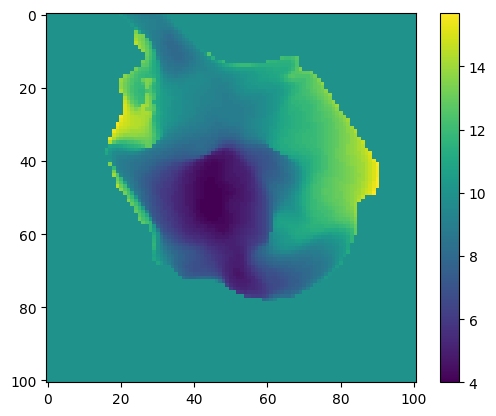

In [282]:
plt.imshow(pred['true_depth'][1, :, :])
plt.colorbar()

np.min(pred['true_depth'][1,:,:])

-0.010488065

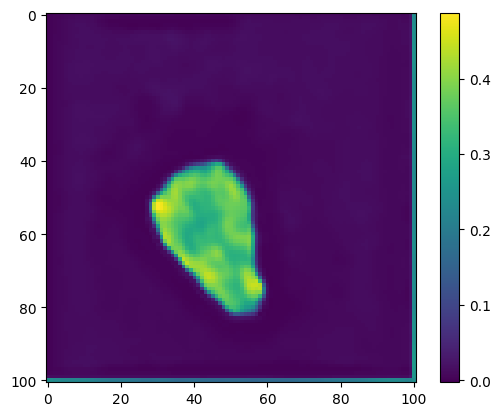

In [283]:


plt.imshow(pred['pred_depth'][1, :, :])
plt.colorbar()

np.min(pred['pred_depth'][5,:,:])